In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from falsb4mpa.dataset.utils import bucket
import matplotlib.pyplot as plt 
import pandas as pd
import seaborn as sns

# Reading data

In [3]:
data = pd.read_csv("../../../data/raw/compas/compas.csv", index_col=0)

In [4]:
data.head()

,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,juv_fel_count,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
id,,,,,,,,,,,,,,,,,,,,,
1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,0,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,0,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,0,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,0,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,0,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0


In [54]:
data.duplicated().sum()

np.int64(0)

In [24]:
print(data.columns)

Index(['name', 'first', 'last', 'compas_screening_date', 'sex', 'dob', 'age',
       'age_cat', 'race', 'juv_fel_count', 'decile_score', 'juv_misd_count',
       'juv_other_count', 'priors_count', 'days_b_screening_arrest',
       'c_jail_in', 'c_jail_out', 'c_case_number', 'c_offense_date',
       'c_arrest_date', 'c_days_from_compas', 'c_charge_degree',
       'c_charge_desc', 'is_recid', 'r_case_number', 'r_charge_degree',
       'r_days_from_arrest', 'r_offense_date', 'r_charge_desc', 'r_jail_in',
       'r_jail_out', 'violent_recid', 'is_violent_recid', 'vr_case_number',
       'vr_charge_degree', 'vr_offense_date', 'vr_charge_desc',
       'type_of_assessment', 'decile_score.1', 'score_text', 'screening_date',
       'v_type_of_assessment', 'v_decile_score', 'v_score_text',
       'v_screening_date', 'in_custody', 'out_custody', 'priors_count.1',
       'start', 'end', 'event', 'two_year_recid'],
      dtype='object')


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7214 entries, 1 to 11001
Data columns (total 52 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   name                     7214 non-null   object 
 1   first                    7214 non-null   object 
 2   last                     7214 non-null   object 
 3   compas_screening_date    7214 non-null   object 
 4   sex                      7214 non-null   object 
 5   dob                      7214 non-null   object 
 6   age                      7214 non-null   int64  
 7   age_cat                  7214 non-null   object 
 8   race                     7214 non-null   object 
 9   juv_fel_count            7214 non-null   int64  
 10  decile_score             7214 non-null   int64  
 11  juv_misd_count           7214 non-null   int64  
 12  juv_other_count          7214 non-null   int64  
 13  priors_count             7214 non-null   int64  
 14  days_b_screening_arrest  690

In [53]:
data.isna().sum()

name                          0
first                         0
last                          0
compas_screening_date         0
sex                           0
dob                           0
age                           0
age_cat                       0
race                          0
juv_fel_count                 0
decile_score                  0
juv_misd_count                0
juv_other_count               0
priors_count                  0
days_b_screening_arrest     307
c_jail_in                   307
c_jail_out                  307
c_case_number                22
c_offense_date             1159
c_arrest_date              6077
c_days_from_compas           22
c_charge_degree               0
c_charge_desc                29
is_recid                      0
r_case_number              3743
r_charge_degree            3743
r_days_from_arrest         4898
r_offense_date             3743
r_charge_desc              3801
r_jail_in                  4898
r_jail_out                 4898
violent_

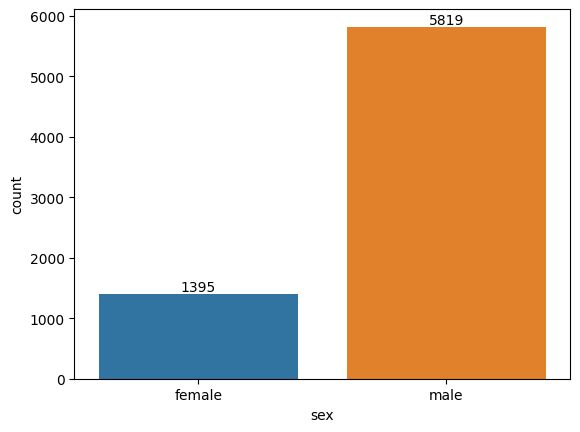

In [14]:
sex_series = pd.get_dummies(data['sex']).astype(int)['Male']
cols = ['sex', 'count']
sex = ['female', 'male']
res_df = pd.DataFrame(columns=cols, dtype='object')

train_counts = sex_series.value_counts()
train_df = pd.DataFrame(
    data=[
        [sex[0], train_counts[0]],
        [sex[1], train_counts[1]]
    ],
    columns=cols
)

res_df = pd.concat([train_df])

for i in res_df.index:
    count = res_df.loc[i, 'count']
    y = res_df.loc[i, 'count']
    plt.annotate(count, (i, y), ha="center", va="bottom")

sns.barplot(x='sex',y='count',data=res_df,hue='sex', dodge=False)
# plt.legend(loc="upper right")
plt.legend([], frameon=False)
plt.show()


<Axes: xlabel='race'>

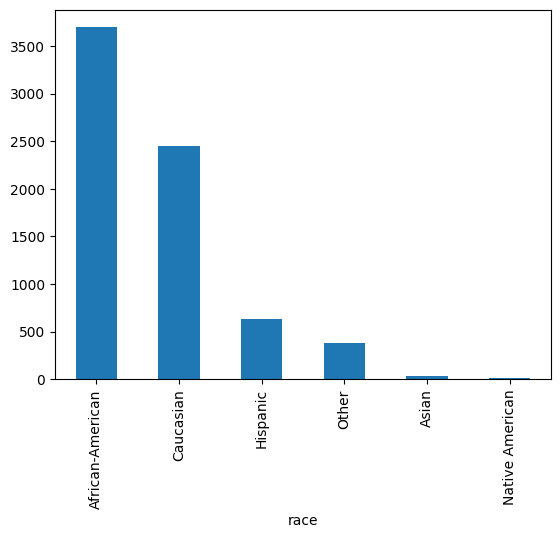

In [22]:
data['race'].value_counts().plot(kind="bar")

<Axes: xlabel='age_cat'>

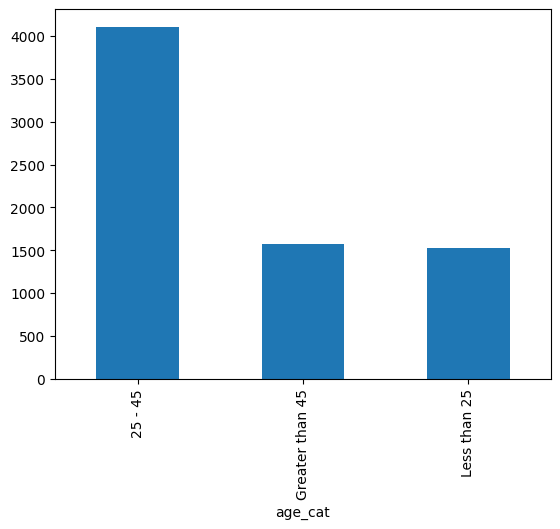

In [23]:
data['age_cat'].value_counts().plot(kind="bar")

two_year_recid
0    3963
1    3251
Name: count, dtype: int64


<Axes: xlabel='two_year_recid'>

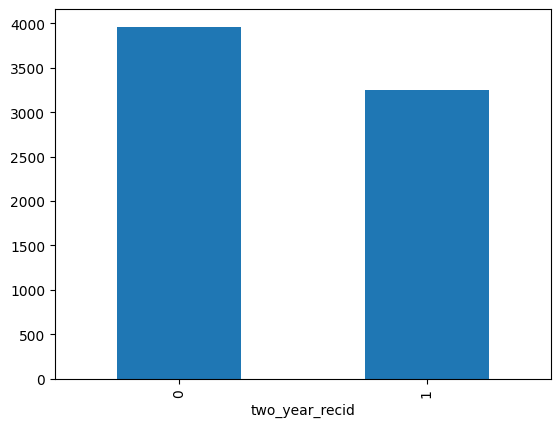

In [33]:
print(data['two_year_recid'].value_counts())
data['two_year_recid'].value_counts().plot(kind='bar')

decile_score
1     1440
2      941
4      769
3      747
5      681
6      641
7      592
8      512
9      508
10     383
Name: count, dtype: int64


<Axes: xlabel='decile_score'>

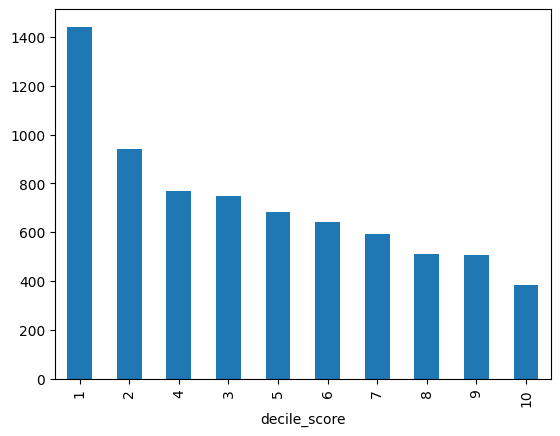

In [31]:
print(data['decile_score'].value_counts())
data['decile_score'].value_counts().plot(kind='bar')

<Axes: xlabel='high_risk'>

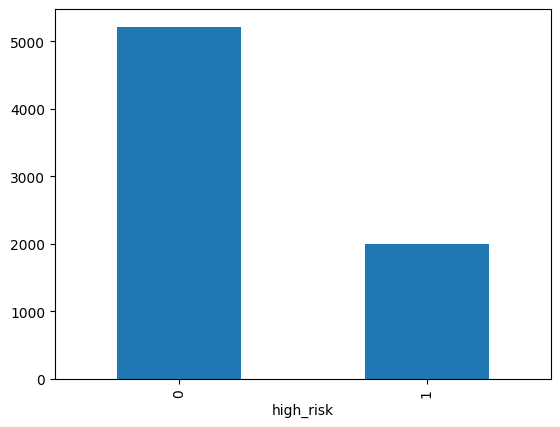

In [32]:
data['high_risk'] = (data['decile_score'] >= 7).astype(int)
data['high_risk'].value_counts().plot(kind='bar')

<Axes: xlabel='score_text'>

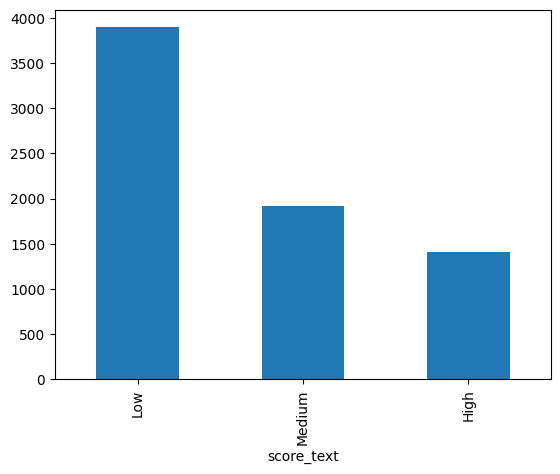

In [ ]:
data['score_text'].value_counts().plot(kind='bar')

<Axes: xlabel='priors_count'>

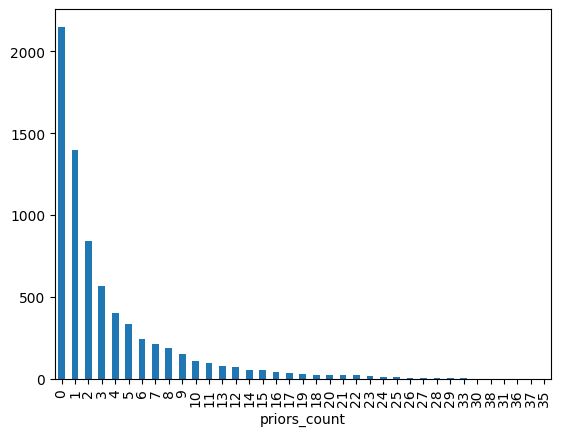

In [37]:
data['priors_count'].value_counts().plot(kind='bar') #MinMax

In [38]:
data['c_case_number'].value_counts()

c_case_number
13011352CF10A    1
10014332CF10A    1
13023525MM10A    1
14006900CF10A    1
14011664MM10A    1
                ..
13002949MM10A    1
14002664MM10A    1
13007972MM10A    1
13004581CF10A    1
14008895CF10A    1
Name: count, Length: 7192, dtype: int64

<Axes: xlabel='c_charge_degree'>

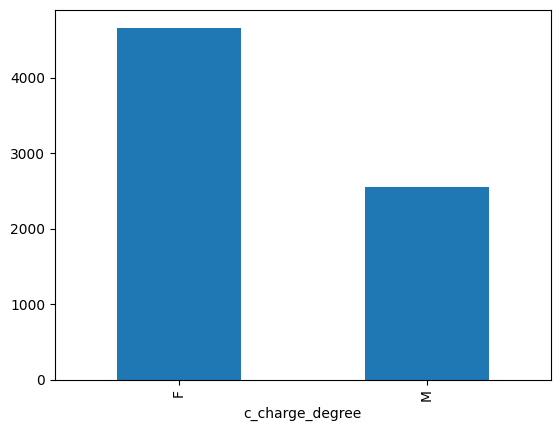

In [40]:
data['c_charge_degree'].value_counts().plot(kind='bar')

<Axes: xlabel='r_charge_degree'>

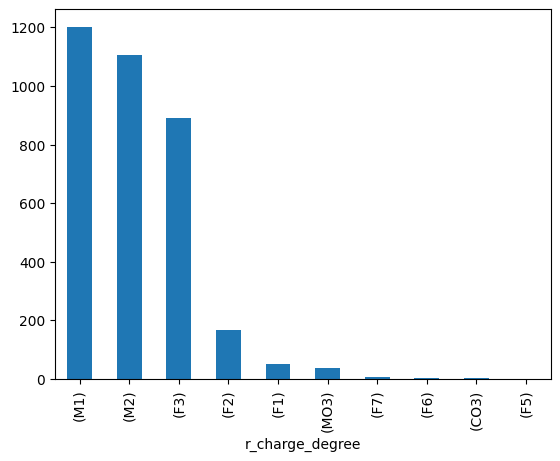

In [41]:
data['r_charge_degree'].value_counts().plot(kind='bar')

In [43]:
data['r_case_number'].value_counts()

r_case_number
13009779CF10A    1
15000565MM30A    1
13007620MM10A    1
14012666TC10A    1
13024813TC10A    1
                ..
14100546TC30A    1
14076038TC30A    1
13012908CF10A    1
14003224CF10A    1
15008160TC10A    1
Name: count, Length: 3471, dtype: int64

In [45]:
data['r_days_from_arrest'].value_counts()

r_days_from_arrest
 0.0      1676
 1.0       289
 51.0        7
 78.0        6
-1.0         6
          ... 
 394.0       1
 70.0        1
 396.0       1
 721.0       1
 175.0       1
Name: count, Length: 201, dtype: int64

In [52]:
data[data['r_days_from_arrest'] != -1]['r_days_from_arrest'].value_counts()

r_days_from_arrest
0.0      1676
1.0       289
51.0        7
78.0        6
77.0        6
         ... 
394.0       1
70.0        1
396.0       1
721.0       1
175.0       1
Name: count, Length: 200, dtype: int64